**This is an implementation of the Quickhull Algorithm in Python.** 

*This algorithm is used to find the convex hull of a set of points in a plane. It works by recursively dividing the point set into two subsets and finding the convex hull for each subset*

In [67]:
# Import Python Modules
import matplotlib.pyplot as plt
import random

[(0.9745343811209292, 0.17689215858734986), (0.8117920852406495, 0.880547907876462), (0.6950083984390766, 0.8187000370895362), (0.152649154521998, 0.2314115992523953), (0.8129474539058518, 0.5100444464827051)]


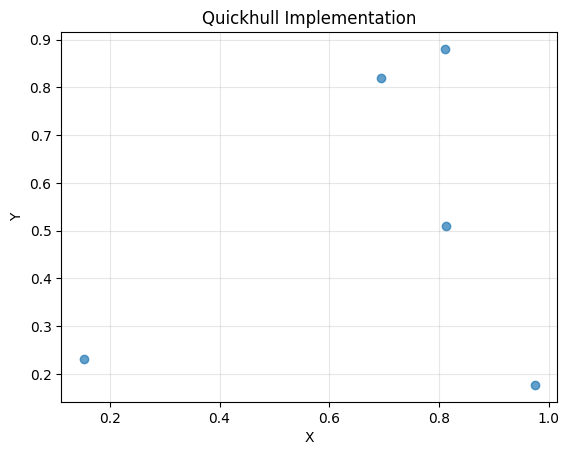

In [68]:
n_points = 5
points = [(random.random(), random.random()) for _ in range(n_points)]

print(points)

x = [p[0] for p in points]
y = [p[1] for p in points]

plt.scatter(x, y, alpha = 0.7)
plt.title("Quickhull Implementation")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha = 0.3)
plt.show()

In [69]:
def perpendicular_distance(p1, p2, p):
    """
    Finds the distance from point p to the line that joins through points p1, p2. This is the determinant of the vectors

    Arguments:
        p1 -- point 1 [x1, y1]
        p2 -- point 2 [x2, y2]
        p  -- point to find distance to line [x, y]

    Return: Distance from point p to the line through p1 and p2
    """

    return abs((p[1] - p1[1]) * (p2[0] - p1[0]) - (p2[1] - p1[1]) * (p[0] - p1[1]))
    

In [ ]:
# Quickhull Algorithm Implementation
def quickhull(points):
    """
    Quickhull algorithm to find the convex hull of a set of points in a 2D space.
    Arguments:
        points -- list of points [[x1, y1], [x2, y2], ...]
    Return: A list of points that represent the convex hull.
    """
    
    # Base Case
    if len(points) <= 2:
        return("This is the convex hull, all of the points are a part of it", points)
    
    #Find the leftmost and rightmost points
    def find_outside_points(p1, p2, points):
        """
        Finds the points that outside the convex hull.
        Arguments:
            p1 -- point 1 [x1, y1]
            p2 -- point 2 [x2, y2]
            points -- list of points [[x1, y1], [x2, y2], ...]

        Return: A list of points that are outside the convex hull.
        """
        if not points:
            return []
        farthest_point = max(points, key=lambda p: perpendicular_distance(p1, p2, p))
        next_point = [p for p in points if perpendicular_distance(p1, farthest_point, p) > 0]
        return find_outside_points(p1, farthest_point, next_point) + farthest_point + find_outside_points(farthest_point, p2, next_point)
        

    min_point = min(points)
    max_point = max(points)
    hull = find_outside_points(min_point, max_point, points) + find_outside_points(max_point, min_point, points)
    return sorted(set(hull))

convex_hull = quickhull(points)
convex_x = [p[0] for p in convex_hull]
convex_y = [p[1] for p in convex_hull]
plt.scatter(convex_x, convex_y, alpha = 0.7)
plt.title("Quickhull Implementation")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha = 0.3)
plt.show()        

RecursionError: maximum recursion depth exceeded